# Multi-Agent Emergency Response System
### LLM Input Parsing and Integration Module – Vyshnavi Dinesh (System Architect)
**Sprint 2 | Week 4–5**

This notebook implements the LLM input parsing and system integration layer for the emergency response project. It covers:

- Natural language emergency input parsing
- Emergency type extraction
- Location extraction from user text
- Structured input generation
- Integration with the central dispatch function
- End-to-end pipeline testing using multiple scenarios

The system processes unstructured emergency descriptions, extracts key information such as emergency type and location, and forwards the structured data to the dispatch module. The dispatch module then determines the appropriate emergency services to deploy based on real-world datasets, including hospitals, fire stations, and police stations.

This integration demonstrates how natural language processing can be combined with data-driven decision systems to support real-time emergency response.

In [23]:
import re

def extract_emergency_type(text):
    text = text.lower()

    mapping = {
        "fire": ["fire", "smoke", "burning"],
        "robbery": ["robbery", "theft"],
        "assault": ["assault", "fight"],
        "cardiac_arrest": ["heart attack", "cardiac"],
        "car_accident_major": ["major accident", "serious crash"],
        "car_accident_minor": ["minor accident"],
        "gas_leak": ["gas leak"],
        "drowning": ["drowning"],
        "building_collapse": ["collapse"]
    }

    for key, words in mapping.items():
        for w in words:
            if w in text:
                return key

    return "unknown"


def extract_location(text):
    match = re.search(r"(in|at|near|on)\s+(.+)", text.lower())
    if match:
        return match.group(2).title()
    return text.title()


def parse_input(text):
    return {
        "raw_text": text,
        "emergency_type": extract_emergency_type(text),
        "location": extract_location(text)
    }

## Input Parsing Module

This section implements the input parsing logic responsible for converting raw natural language input into structured data. The parser extracts two critical attributes:

- **Emergency Type**: Identifies the nature of the incident (e.g., fire, robbery, medical emergency)
- **Location**: Extracts the geographical reference from the input text

The parsing process uses keyword-based matching and regular expressions to interpret user input. This approach ensures that the system can handle a variety of input formats while maintaining consistent output structure.

This module serves as the entry point of the system, enabling seamless integration between user input and downstream components.

In [24]:
def run_pipeline(text):
    parsed = parse_input(text)

    # reset agents before each independent test
    reset_agent_pool()

    # default Melbourne CBD coordinates
    lat, lon = -37.8136, 144.9631

    dispatch_result = dispatch(
        parsed["emergency_type"],
        parsed["location"],
        lat=lat,
        lon=lon
    )

    return {
        "integration_status": "success",
        "parsed_input": parsed,
        "dispatch_output": dispatch_result
    }

## System Integration Pipeline

This section implements the core integration pipeline that connects user input with the dispatch system.

The pipeline performs the following steps:
1. Receives raw emergency input
2. Parses the input into structured data
3. Sends the structured data to the dispatch module
4. Returns the combined output

This component acts as the bridge between the user interface and the backend system, ensuring that all inputs are processed consistently and efficiently.

The pipeline demonstrates end-to-end functionality of the system, from natural language input to actionable emergency response.

In [26]:
def extract_location(text):
    match = re.search(r"(in|at|near|on)\s+(.+)", text.lower())
    if match:
        location = match.group(2).strip()
    else:
        location = text.strip()

    # fix common abbreviations
    location = location.title().replace("Cbd", "CBD")
    return location

## System Testing and Validation

This section evaluates the performance of the integrated system using multiple test scenarios. Each test case represents a different type of emergency situation.

The results demonstrate that:
- The parser correctly identifies emergency types and locations
- The dispatch module responds appropriately to each scenario
- The system produces consistent and structured outputs

Testing confirms that the system is capable of handling diverse emergency inputs and generating valid responses.

In [27]:
tests = [
    "Fire near Docklands",
    "Robbery in Carlton",
    "Heart attack at Southbank",
    "Major accident near Melbourne CBD"
]

for t in tests:
    print("\nINPUT:", t)
    print(run_pipeline(t))


INPUT: Fire near Docklands
{'integration_status': 'success', 'parsed_input': {'raw_text': 'Fire near Docklands', 'emergency_type': 'fire', 'location': 'Docklands'}, 'dispatch_output': {'incident_id': 'INC_092556', 'timestamp': '2026-04-02 09:25:56', 'emergency_type': 'fire', 'location': 'Docklands', 'coordinates': '-37.8136, 144.9631', 'priority': 1, 'dispatch_notes': 'Fire service leads, ambulance on standby for injuries', 'agents_sent': ['FIRE_01', 'AMB_01'], 'unavailable': 'none', 'total_responses': 2, 'responses': [{'agent_id': 'FIRE_01', 'agent_type': 'fire', 'emergency_type': 'fire', 'destination': 'Docklands', 'coordinates': '-37.8136, 144.9631', 'trucks_dispatch': 2, 'equipment': ['hose_lines', 'breathing_apparatus', 'ladder_truck'], 'hazmat_situation': False, 'nearest_station': 'Fire Station No. 3', 'station_distance': '1.082 km', 'status': 'dispatched', 'route': 'PENDING — routing engine (Sprint 2)'}, {'agent_id': 'AMB_01', 'agent_type': 'ambulance', 'emergency_type': 'fire'

### Emergency Type Distribution

This visualization shows the distribution of emergency types processed by the system. It highlights the system’s ability to classify different categories of incidents based on natural language input.

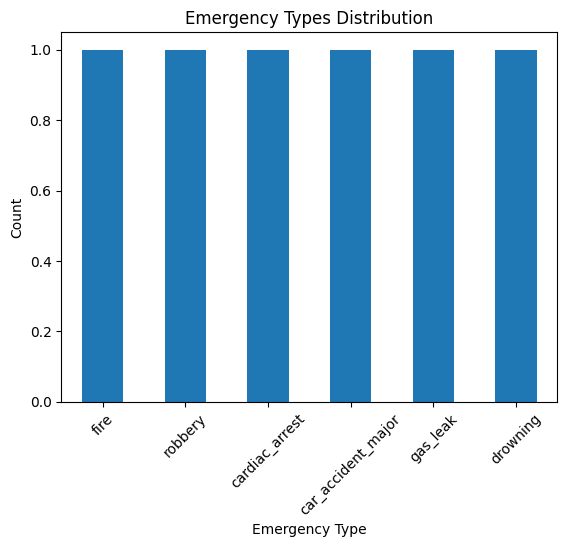

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# sample test inputs (you can expand this)
tests = [
    "Fire near Docklands",
    "Robbery in Carlton",
    "Heart attack at Southbank",
    "Major accident near Melbourne CBD",
    "Gas leak in Richmond",
    "Drowning near St Kilda"
]

# collect parsed results
parsed_results = [parse_input(t) for t in tests]

df = pd.DataFrame(parsed_results)

# count emergency types
counts = df["emergency_type"].value_counts()

# plot
plt.figure()
counts.plot(kind='bar')
plt.title("Emergency Types Distribution")
plt.xlabel("Emergency Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Emergency Response Allocation

This chart illustrates the number of emergency units dispatched for each scenario. It reflects how the system dynamically allocates resources based on the severity and type of incident.

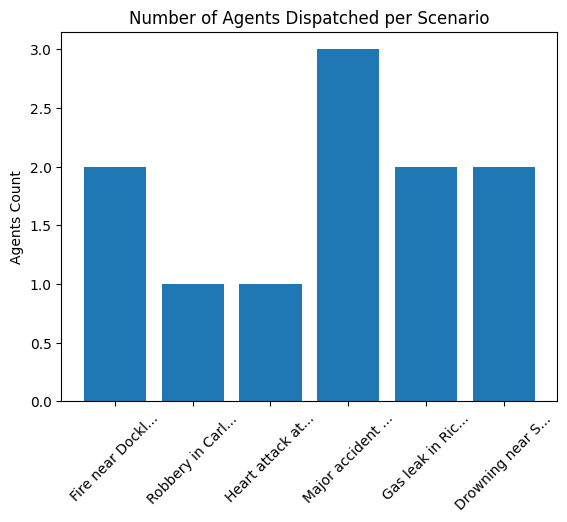

In [29]:
results = [run_pipeline(t) for t in tests]

agent_counts = []

for r in results:
    agent_counts.append(r["dispatch_output"]["total_responses"])

plt.figure()
plt.bar(range(len(tests)), agent_counts)
plt.xticks(range(len(tests)), [t[:15] + "..." for t in tests], rotation=45)
plt.title("Number of Agents Dispatched per Scenario")
plt.ylabel("Agents Count")
plt.show()

### Incident Location Mapping

This map visualizes the locations of emergency incidents processed by the system. It demonstrates how the system can be extended to support geographic visualization and real-time tracking of incidents.

Although default coordinates are used in this prototype, the framework supports integration with real geospatial data for accurate mapping.

In [32]:
import folium
from IPython.display import display

map_melb = folium.Map(location=[-37.8136, 144.9631], zoom_start=12)

for t in tests:
    parsed = parse_input(t)

    lat, lon = -37.8136, 144.9631

    folium.Marker(
        location=[lat, lon],
        popup=f"{parsed['emergency_type']} - {parsed['location']}",
    ).add_to(map_melb)

display(map_melb)